# 國小兒童近視比例 - 第1個方法
## Pseudo inverse

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## 輸入資料

float64 6 float64 6


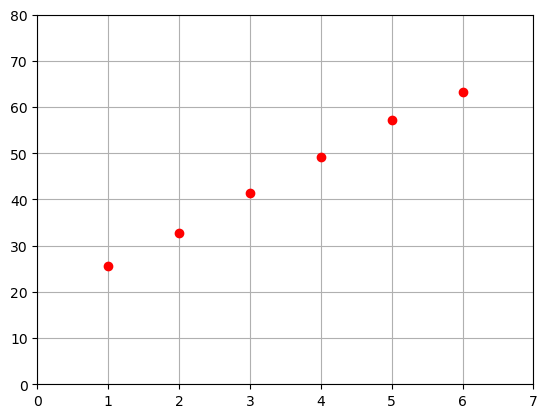

In [2]:
x = np.array([1.0,2.0,3.0,4.0,5.0,6.0])
y = np.array([25.64,32.71,41.33,49.13,57.21,63.21])
print(x.dtype, x.size, y.dtype, y.size)
plt.plot(x,y,'ro')
plt.xlim([0,7])
plt.ylim([0,80])
plt.grid()

# 製造雜訊

In [3]:
mu, sigma = 0, 1 # mean and standard deviation
x_noise = 0.2*np.random.normal(mu, sigma, 600)
y_noise = 2.0*np.random.normal(mu, sigma, 600)

# 將雜訊加到原始數據

float64 600 float64 600


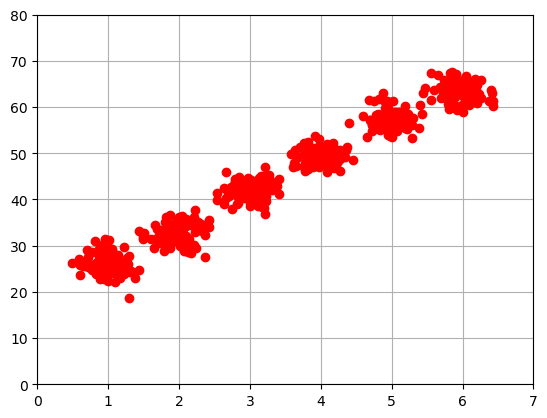

In [4]:
x_new = np.zeros(600)
y_new = np.zeros(600)
for i in range(0,600):
    r1 = int(i/100)
    x_new[i] = x[r1] + x_noise[i]
    y_new[i] = y[r1] + y_noise[i]

#x = x_new
#y = y_new  
x = x_new
y = y_new  
print(x.dtype, x.size, y.dtype, y.size)

plt.plot(x,y,'ro')
plt.xlim([0,7])
plt.ylim([0,80])
plt.grid()

# 設定 A_matrix and B_matrix

In [5]:
only_one = np.ones(x.size)
A_array = (x,only_one)
A_tmp = np.asmatrix(A_array)
A_matrix = np.matrix.transpose(A_tmp)

B_tmp = np.asmatrix(y)
B_matrix = np.matrix.transpose(B_tmp)

print(A_matrix,'\n')
print(A_matrix.dtype,A_matrix.size,'\n')
print(B_matrix,'\n')
print(B_matrix.dtype,B_matrix.size,'\n')

[[1.16563932 1.        ]
 [1.32078409 1.        ]
 [0.77799025 1.        ]
 ...
 [5.82898696 1.        ]
 [5.89234009 1.        ]
 [5.90043111 1.        ]] 

float64 1200 

[[25.67918523]
 [24.49876025]
 [25.80719994]
 [24.69019548]
 [25.85178739]
 [24.26861149]
 [24.28180357]
 [26.15759413]
 [28.23191083]
 [26.53164532]
 [25.34877866]
 [25.95694734]
 [28.10736748]
 [24.78598931]
 [23.50270541]
 [23.06538454]
 [24.74163329]
 [23.03738882]
 [29.33610545]
 [29.32801878]
 [27.66869655]
 [29.22559205]
 [24.68306151]
 [25.46530736]
 [24.99834653]
 [22.38446523]
 [25.59259774]
 [25.71390694]
 [24.7579721 ]
 [25.86956482]
 [25.26101977]
 [18.72129187]
 [24.57026485]
 [24.68571573]
 [24.89768696]
 [31.54782286]
 [29.64919071]
 [31.18142864]
 [25.34659689]
 [27.50322593]
 [24.21888125]
 [27.4203325 ]
 [27.99279868]
 [28.57871423]
 [25.29884509]
 [23.57463084]
 [24.5198887 ]
 [26.67145613]
 [27.98393256]
 [22.97148073]
 [25.18726611]
 [25.74604249]
 [27.0640275 ]
 [24.87580161]
 [27.39360035]
 [

# 做 Pseudo inverse, 計算 X_matrix

In [6]:
A_transpose = np.matrix.transpose(A_matrix)
A_square = A_transpose*A_matrix
A_square_inverse = np.linalg.inv(A_square)

X_matrix = A_square_inverse * A_transpose * B_matrix
print(A_square,'\n')
print(A_square_inverse,'\n')
print(X_matrix,'\n')

[[9044.25412565 2090.32984475]
 [2090.32984475  600.        ]] 

[[ 0.0005676  -0.00197747]
 [-0.00197747  0.00855594]] 

[[ 7.60358314]
 [18.55404725]] 



# 列印結果

# Plot the fitted line

In [7]:
x_fit = np.zeros(2)
y_fit = np.zeros(2)
x_fit[0] = 1
x_fit[1] = 6
m_slope = X_matrix[0]
b_bias = X_matrix[1]
y_fit[0] = m_slope*1 + b_bias
y_fit[1] = m_slope*6 + b_bias

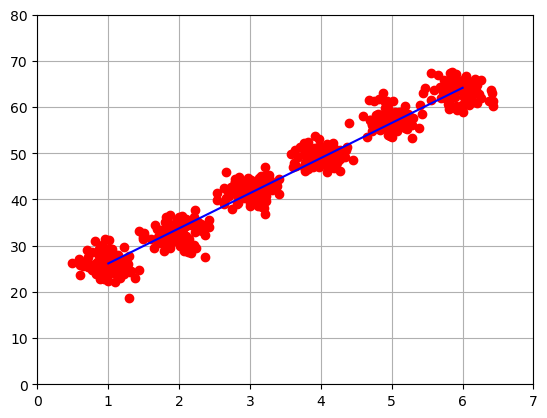

In [8]:
plt.xlim([0,7])
plt.ylim([0,80])
plt.plot(x,y,'ro')
plt.plot(x_fit,y_fit,'b-')
plt.grid()
plt.show()